**Primera evaluación**

**Implementar KNN desde cero**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import kagglehub
from kagglehub import KaggleDatasetAdapter

# ============================================================
# 1. CARGAR DATASET
# ============================================================

file_path = "Dataset v1.0.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "schiaffino89/lugares-aptos-para-trabajar",
    file_path
)

print("Dimensiones:", df.shape)
print("\nPrimeros registros:")
print(df.head())

print("\nDistribución de Target:")
print(df["Target"].value_counts())

# ============================================================
# 2. SEPARAR CARACTERÍSTICAS Y TARGET
# ============================================================

X = df.drop(columns=["Lugar", "Target"]).values
y = df["Target"].values
lugares = df["Lugar"].values

print("\nNúmero de características:", X.shape[1])

# ============================================================
# 3. DISTANCIA EUCLIDIANA
# ============================================================

def distancia_euclidiana(punto1, punto2):
    return np.sqrt(np.sum((punto1 - punto2) ** 2))

# ============================================================
# 4. KNN MANUAL
# ============================================================

def knn_predecir(X_train, y_train, nuevo_registro, k=3):

    distancias = []

    for i in range(len(X_train)):

        distancia = distancia_euclidiana(
            X_train[i],
            nuevo_registro
        )

        distancias.append(
            (distancia, y_train[i])
        )

    distancias.sort(key=lambda x: x[0])

    vecinos = distancias[:k]

    clases_vecinos = [
        vecino[1]
        for vecino in vecinos
    ]

    valores, conteos = np.unique(
        clases_vecinos,
        return_counts=True
    )

    return valores[np.argmax(conteos)]

/tmp/ipykernel_769/567355548.py:14: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'lugares-aptos-para-trabajar' dataset.
Dimensiones: (65, 13)

Primeros registros:
                       Lugar  silencio  sombra  aire_acondicionado  \
0               Plaza Cosmos         0       0                   0   
1  Laboratorio 4 de posgrado         1       1                   1   
2         Domo de enfermeria         0       1                   1   
3    Mesas de trabajo social         0       1                   1   
4          Medios didacticos         1       1                   1   

   soporte_para_trabajar  asientos  asientos_comodos  enchufes  \
0                      1         1                 1         0   
1                      1         1                 1         1   
2                      0         1                 0         0   
3                      1         1                 1         1   
4                      0         1                 1         0   

   flujo_personas  banos_cerca  cafeteria_cerca  internet

**División entrenamiento y prueba**

In [7]:
# ============================================================
# 1. DIVISIÓN ENTRENAMIENTO / PRUEBA
# ============================================================

np.random.seed(42)

indices = np.arange(len(X))
np.random.shuffle(indices)

limite = int(len(X) * 0.80)

indices_train = indices[:limite]
indices_test = indices[limite:]

X_train = X[indices_train]
X_test = X[indices_test]

y_train = y[indices_train]
y_test = y[indices_test]

lugares_test = lugares[indices_test]

print("Entrenamiento:", len(X_train))
print("Prueba:", len(X_test))

Entrenamiento: 52
Prueba: 13


**Experimentar con diferentes valores de K**

   k  Correctos  Total  Accuracy  Accuracy (%)
0  1         13     13  1.000000    100.000000
1  2         13     13  1.000000    100.000000
2  3         12     13  0.923077     92.307692
3  4         13     13  1.000000    100.000000
4  5         12     13  0.923077     92.307692
5  6         12     13  0.923077     92.307692
6  7         11     13  0.846154     84.615385
7  8         11     13  0.846154     84.615385
8  9         11     13  0.846154     84.615385


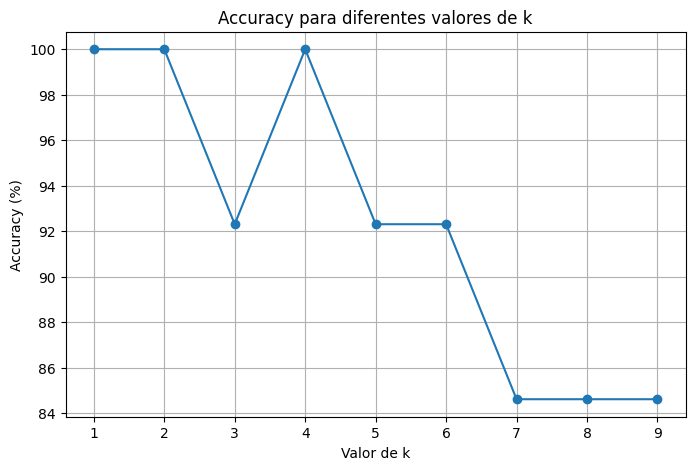

In [8]:
# ============================================================
# 2. PROBAR DIFERENTES VALORES DE K
# ============================================================

valores_k = [1, 2, 3, 4, 5, 6, 7, 8, 9]

resultados_k = []

for k in valores_k:

    predicciones = []

    for registro in X_test:

        prediccion = knn_predecir(
            X_train,
            y_train,
            registro,
            k
        )

        predicciones.append(prediccion)

    predicciones = np.array(predicciones)

    correctos = np.sum(predicciones == y_test)
    accuracy = correctos / len(y_test)

    resultados_k.append({
        "k": k,
        "Correctos": correctos,
        "Total": len(y_test),
        "Accuracy": accuracy,
        "Accuracy (%)": accuracy * 100
    })

# ============================================================
# 3. MOSTRAR RESULTADOS
# ============================================================

tabla_resultados = pd.DataFrame(resultados_k)

print(tabla_resultados)

# ============================================================
# 4. GRÁFICA
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    tabla_resultados["k"],
    tabla_resultados["Accuracy (%)"],
    marker="o"
)

plt.xlabel("Valor de k")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy para diferentes valores de k")
plt.xticks(valores_k)
plt.grid()

plt.show()

In [9]:
# ============================================================
# VALIDACIÓN CRUZADA MANUAL - 5 FOLDS
# ============================================================

np.random.seed(42)

indices = np.arange(len(X))
np.random.shuffle(indices)

folds = np.array_split(indices, 5)

valores_k = [1, 2, 3, 5, 7, 9]

resultados_cv = []

for k in valores_k:

    accuracies = []

    for i in range(5):

        indices_test_fold = folds[i]

        indices_train_fold = np.concatenate([
            folds[j]
            for j in range(5)
            if j != i
        ])

        X_train_fold = X[indices_train_fold]
        y_train_fold = y[indices_train_fold]

        X_test_fold = X[indices_test_fold]
        y_test_fold = y[indices_test_fold]

        predicciones = []

        for registro in X_test_fold:

            prediccion = knn_predecir(
                X_train_fold,
                y_train_fold,
                registro,
                k
            )

            predicciones.append(prediccion)

        predicciones = np.array(predicciones)

        accuracy = np.mean(
            predicciones == y_test_fold
        )

        accuracies.append(accuracy)

    accuracy_promedio = np.mean(accuracies)

    resultados_cv.append({
        "k": k,
        "Fold 1": accuracies[0],
        "Fold 2": accuracies[1],
        "Fold 3": accuracies[2],
        "Fold 4": accuracies[3],
        "Fold 5": accuracies[4],
        "Promedio": accuracy_promedio,
        "Promedio (%)": accuracy_promedio * 100
    })

tabla_cv = pd.DataFrame(resultados_cv)

print(tabla_cv)

mejor_fila = tabla_cv.loc[
    tabla_cv["Promedio"].idxmax()
]

print(
    f"\nMejor k: {int(mejor_fila['k'])}"
)

print(
    f"Accuracy promedio: "
    f"{mejor_fila['Promedio'] * 100:.2f}%"
)

   k    Fold 1    Fold 2    Fold 3    Fold 4    Fold 5  Promedio  Promedio (%)
0  1  0.846154  1.000000  0.923077  0.846154  1.000000  0.923077     92.307692
1  2  0.846154  1.000000  0.923077  0.923077  1.000000  0.938462     93.846154
2  3  0.846154  1.000000  0.923077  0.846154  0.923077  0.907692     90.769231
3  5  0.769231  1.000000  0.923077  0.769231  0.923077  0.876923     87.692308
4  7  0.769231  0.923077  0.923077  0.846154  0.846154  0.861538     86.153846
5  9  0.692308  0.846154  0.923077  0.846154  0.846154  0.830769     83.076923

Mejor k: 2
Accuracy promedio: 93.85%


**Comparación con scikit learn**

COMPARACIÓN KNN MANUAL VS SCIKIT-LEARN
 k  Accuracy Manual  Accuracy Scikit-Learn  Coincidencia
 1           1.0000                 1.0000        1.0000
 2           1.0000                 1.0000        1.0000
 3           0.9231                 0.9231        1.0000
 4           1.0000                 0.9231        0.9231
 5           0.9231                 0.9231        1.0000
 6           0.9231                 0.9231        1.0000
 7           0.8462                 0.8462        1.0000
 8           0.8462                 0.8462        1.0000
 9           0.8462                 0.8462        1.0000


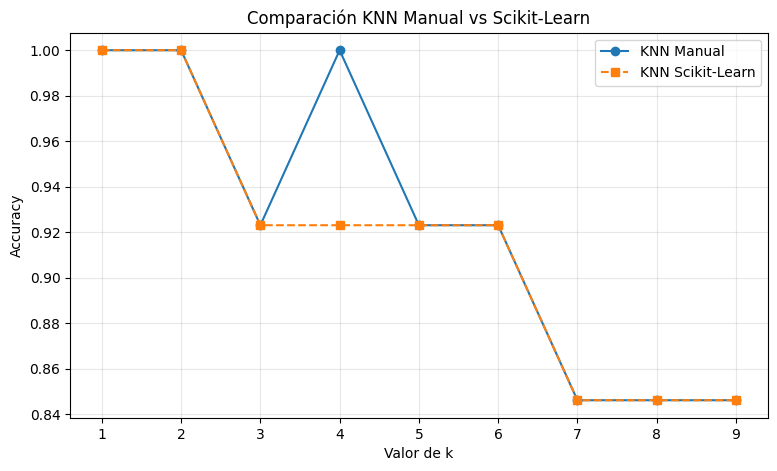

In [10]:
# ============================================================
# 9. COMPARACIÓN CON SCIKIT-LEARN
# ============================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

# Valores de k que se van a comparar
valores_k = [1, 2, 3, 4, 5, 6, 7, 8, 9]

resultados_comparacion = []

for k in valores_k:

    # --------------------------------------------------------
    # KNN IMPLEMENTACIÓN PROPIA
    # --------------------------------------------------------
    predicciones_manual = []

    for registro in X_test:
        prediccion = knn_predecir(
            X_train,
            y_train,
            registro,
            k=k
        )
        predicciones_manual.append(prediccion)

    predicciones_manual = np.array(predicciones_manual)

    accuracy_manual = accuracy_score(
        y_test,
        predicciones_manual
    )

    # --------------------------------------------------------
    # KNN SCIKIT-LEARN
    # --------------------------------------------------------
    modelo_sklearn = KNeighborsClassifier(
        n_neighbors=k
    )

    modelo_sklearn.fit(
        X_train,
        y_train
    )

    predicciones_sklearn = modelo_sklearn.predict(
        X_test
    )

    accuracy_sklearn = accuracy_score(
        y_test,
        predicciones_sklearn
    )

    # --------------------------------------------------------
    # Comparar predicciones
    # --------------------------------------------------------
    coincidencias = np.mean(
        predicciones_manual == predicciones_sklearn
    )

    resultados_comparacion.append({
        "k": k,
        "Accuracy Manual": accuracy_manual,
        "Accuracy Scikit-Learn": accuracy_sklearn,
        "Coincidencia": coincidencias
    })


# ============================================================
# MOSTRAR RESULTADOS
# ============================================================

tabla_comparacion = pd.DataFrame(resultados_comparacion)

print("COMPARACIÓN KNN MANUAL VS SCIKIT-LEARN")
print("=" * 65)

print(
    tabla_comparacion.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# GRÁFICA
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    tabla_comparacion["k"],
    tabla_comparacion["Accuracy Manual"],
    marker="o",
    label="KNN Manual"
)

plt.plot(
    tabla_comparacion["k"],
    tabla_comparacion["Accuracy Scikit-Learn"],
    marker="s",
    linestyle="--",
    label="KNN Scikit-Learn"
)

plt.xlabel("Valor de k")
plt.ylabel("Accuracy")
plt.title("Comparación KNN Manual vs Scikit-Learn")

plt.xticks(valores_k)

plt.grid(alpha=0.3)
plt.legend()

plt.show()

**Metricas de error con K = 2**

KNN SCIKIT-LEARN
k        : 2
Accuracy : 1.0000
ROC-AUC  : 1.0000


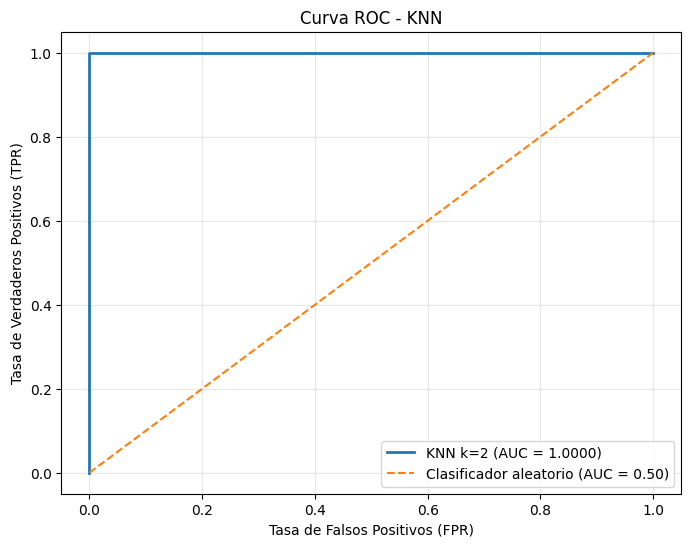

KNN SCIKIT-LEARN
k        : 2
Accuracy : 1.0000
ROC-AUC  : 1.0000


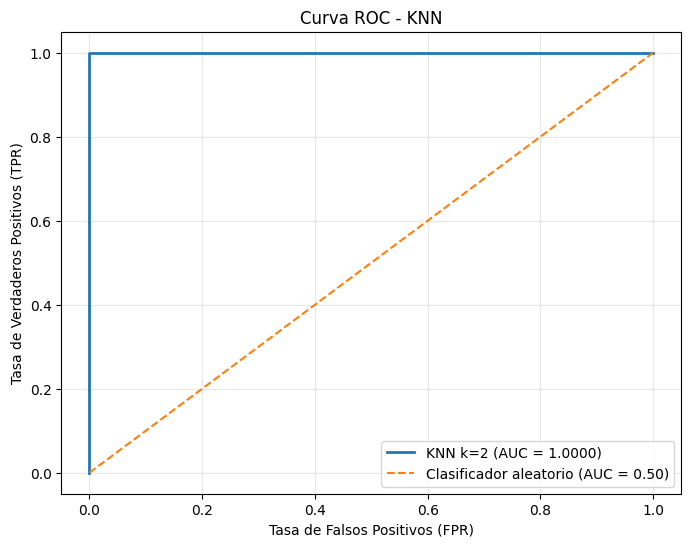

In [14]:
# ============================================================
# ROC-AUC PARA KNN CON SCIKIT-LEARN
# ============================================================

import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve
)

# ------------------------------------------------------------
# 1. Seleccionar k
# ------------------------------------------------------------

k = 2   # Cambiar por el mejor k encontrado anteriormente


# ------------------------------------------------------------
# 2. Crear y entrenar KNN
# ------------------------------------------------------------

modelo_knn = KNeighborsClassifier(
    n_neighbors=k
)

modelo_knn.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# 3. Predicciones
# ------------------------------------------------------------

predicciones_knn = modelo_knn.predict(X_test)

# Probabilidad de pertenecer a la clase positiva (clase 1)
probabilidades_knn = modelo_knn.predict_proba(X_test)[:, 1]


# ------------------------------------------------------------
# 4. Accuracy
# ------------------------------------------------------------

accuracy_knn = accuracy_score(
    y_test,
    predicciones_knn
)


# ------------------------------------------------------------
# 5. ROC-AUC
# ------------------------------------------------------------

roc_auc_knn = roc_auc_score(
    y_test,
    probabilidades_knn
)


print("KNN SCIKIT-LEARN")
print("=" * 40)

print(f"k        : {k}")
print(f"Accuracy : {accuracy_knn:.4f}")
print(f"ROC-AUC  : {roc_auc_knn:.4f}")


# ------------------------------------------------------------
# 6. Calcular curva ROC
# ------------------------------------------------------------

fpr_knn, tpr_knn, thresholds_knn = roc_curve(
    y_test,
    probabilidades_knn
)


# ------------------------------------------------------------
# 7. Graficar curva ROC
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_knn,
    tpr_knn,
    linewidth=2,
    label=f"KNN k={k} (AUC = {roc_auc_knn:.4f})"
)

# Clasificador aleatorio
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificador aleatorio (AUC = 0.50)"
)

plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")

plt.title("Curva ROC - KNN")

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

**Modelo de Regresión Logística**

REGRESIÓN LOGÍSTICA
Accuracy : 0.9231
Precision: 0.9341
Recall   : 0.9231
F1-Score : 0.9231
ROC-AUC  : 0.9762

Matriz de confusión:
[[6 1]
 [0 6]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       0.86      1.00      0.92         6

    accuracy                           0.92        13
   macro avg       0.93      0.93      0.92        13
weighted avg       0.93      0.92      0.92        13



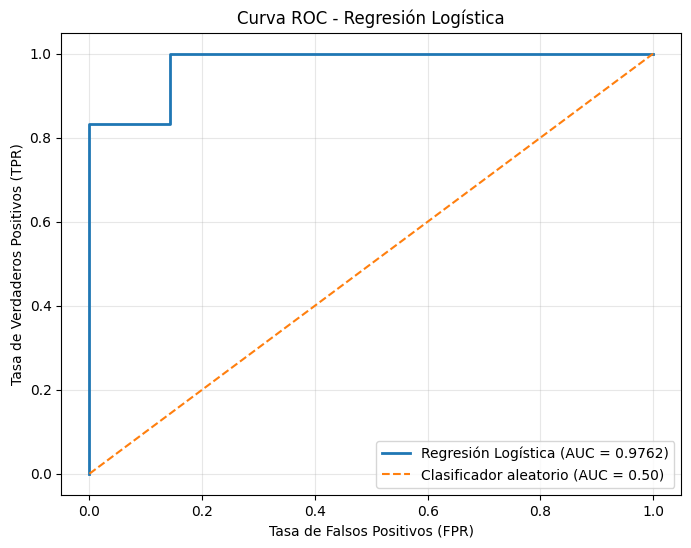

In [12]:
# ============================================================
# 10. MODELO ADICIONAL: REGRESIÓN LOGÍSTICA
#     + MÉTRICAS + MATRIZ DE CONFUSIÓN + CURVA ROC-AUC
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)


# ============================================================
# 1. CREAR EL MODELO
# ============================================================

modelo_logistico = LogisticRegression(
    max_iter=1000
)


# ============================================================
# 2. ENTRENAR EL MODELO
#    Se utiliza la MISMA división de datos usada en KNN
# ============================================================

modelo_logistico.fit(X_train, y_train)


# ============================================================
# 3. REALIZAR PREDICCIONES
# ============================================================

# Predicción de clases
predicciones_logistica = modelo_logistico.predict(X_test)

# Probabilidad de pertenecer a la clase positiva
probabilidades_logistica = modelo_logistico.predict_proba(X_test)[:, 1]


# ============================================================
# 4. CALCULAR MÉTRICAS
# ============================================================

accuracy = accuracy_score(
    y_test,
    predicciones_logistica
)

precision = precision_score(
    y_test,
    predicciones_logistica,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    predicciones_logistica,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    predicciones_logistica,
    average="weighted",
    zero_division=0
)

# ROC-AUC
roc_auc = roc_auc_score(
    y_test,
    probabilidades_logistica
)


# ============================================================
# 5. MOSTRAR MÉTRICAS
# ============================================================

print("REGRESIÓN LOGÍSTICA")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")


# ============================================================
# 6. MATRIZ DE CONFUSIÓN
# ============================================================

matriz = confusion_matrix(
    y_test,
    predicciones_logistica
)

print("\nMatriz de confusión:")
print(matriz)


# ============================================================
# 7. REPORTE DE CLASIFICACIÓN
# ============================================================

print("\nReporte de clasificación:")

print(
    classification_report(
        y_test,
        predicciones_logistica,
        zero_division=0
    )
)


# ============================================================
# 8. CALCULAR CURVA ROC
# ============================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    probabilidades_logistica
)


# ============================================================
# 9. GRAFICAR CURVA ROC
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Regresión Logística (AUC = {roc_auc:.4f})"
)

# Línea de referencia de un clasificador aleatorio
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificador aleatorio (AUC = 0.50)"
)

plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")

plt.title(
    "Curva ROC - Regresión Logística"
)

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

**Presentar los resultados usando la misma métrica:**
Escogimos ROC AUC

KNN MANUAL
k       : 2
ROC-AUC : 1.0000


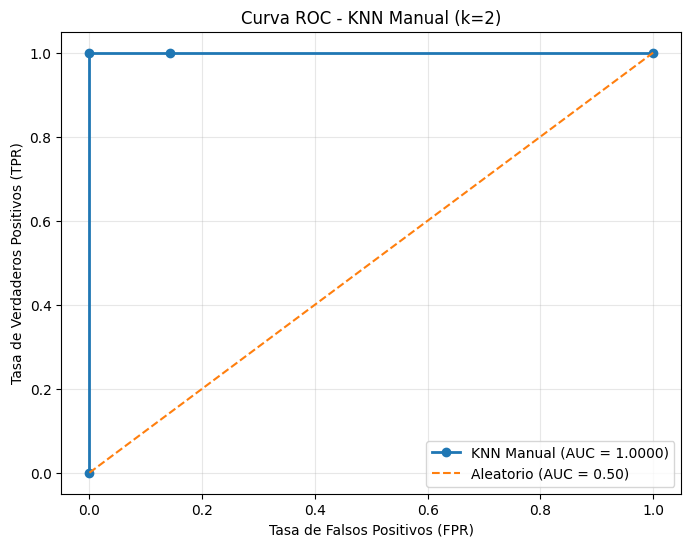

In [20]:
# ============================================================
# ROC-AUC - KNN MANUAL
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, roc_auc_score


# ------------------------------------------------------------
# Función para obtener el score/probabilidad de la clase 1
# ------------------------------------------------------------

def knn_probabilidad(X_train, y_train, nuevo_registro, k=3):

    distancias = []

    for i in range(len(X_train)):

        distancia = distancia_euclidiana(
            X_train[i],
            nuevo_registro
        )

        distancias.append(
            (distancia, y_train[i])
        )

    # Ordenar distancias
    distancias.sort(key=lambda x: x[0])

    # Seleccionar k vecinos
    vecinos = distancias[:k]

    # Obtener clases
    clases_vecinos = [
        vecino[1]
        for vecino in vecinos
    ]

    # Proporción de vecinos de clase 1
    probabilidad_clase_1 = np.mean(
        np.array(clases_vecinos) == 1
    )

    return probabilidad_clase_1


# ------------------------------------------------------------
# Usar el mejor k encontrado
# ------------------------------------------------------------

k = 2  # CAMBIAR por tu mejor k


# ------------------------------------------------------------
# Calcular probabilidades
# ------------------------------------------------------------

probabilidades_knn_manual = []

for registro in X_test:

    probabilidad = knn_probabilidad(
        X_train,
        y_train,
        registro,
        k
    )

    probabilidades_knn_manual.append(
        probabilidad
    )


probabilidades_knn_manual = np.array(
    probabilidades_knn_manual
)


# ------------------------------------------------------------
# Calcular ROC-AUC
# ------------------------------------------------------------

roc_auc_knn_manual = roc_auc_score(
    y_test,
    probabilidades_knn_manual
)


# ------------------------------------------------------------
# Calcular curva ROC
# ------------------------------------------------------------

fpr_knn_manual, tpr_knn_manual, thresholds_knn_manual = roc_curve(
    y_test,
    probabilidades_knn_manual
)


# ------------------------------------------------------------
# Resultados
# ------------------------------------------------------------

print("KNN MANUAL")
print("=" * 40)

print(f"k       : {k}")
print(f"ROC-AUC : {roc_auc_knn_manual:.4f}")


# ------------------------------------------------------------
# Gráfica
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_knn_manual,
    tpr_knn_manual,
    marker="o",
    linewidth=2,
    label=f"KNN Manual (AUC = {roc_auc_knn_manual:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Aleatorio (AUC = 0.50)"
)

plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")

plt.title(
    f"Curva ROC - KNN Manual (k={k})"
)

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

Clases: [0 1]

KNN SCIKIT-LEARN
k        : 2
Accuracy : 1.0000
ROC-AUC  : 1.0000


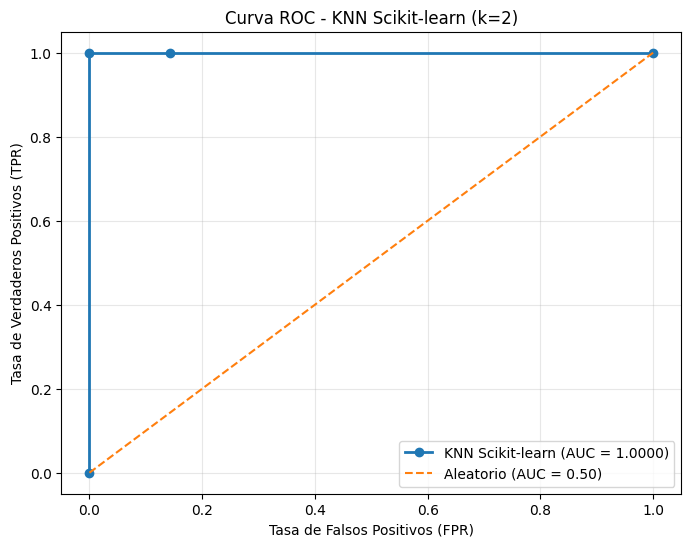

In [22]:
# ============================================================
# KNN - SCIKIT-LEARN
# Accuracy + ROC-AUC
# ============================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Usar el MISMO k que en KNN manual
# ------------------------------------------------------------

k = 2  # CAMBIAR por tu mejor k


# ------------------------------------------------------------
# Crear modelo
# ------------------------------------------------------------

modelo_knn_sklearn = KNeighborsClassifier(
    n_neighbors=k
)


# ------------------------------------------------------------
# Entrenar
# ------------------------------------------------------------

modelo_knn_sklearn.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# Comprobar orden de las clases
# ------------------------------------------------------------

print(
    "Clases:",
    modelo_knn_sklearn.classes_
)


# ------------------------------------------------------------
# Predicciones
# ------------------------------------------------------------

predicciones_knn_sklearn = modelo_knn_sklearn.predict(
    X_test
)


# ------------------------------------------------------------
# Probabilidad de la clase 1
# ------------------------------------------------------------

indice_clase_1 = np.where(
    modelo_knn_sklearn.classes_ == 1
)[0][0]

probabilidades_knn_sklearn = (
    modelo_knn_sklearn.predict_proba(X_test)
    [:, indice_clase_1]
)


# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

accuracy_knn_sklearn = accuracy_score(
    y_test,
    predicciones_knn_sklearn
)


# ------------------------------------------------------------
# ROC-AUC
# ------------------------------------------------------------

roc_auc_knn_sklearn = roc_auc_score(
    y_test,
    probabilidades_knn_sklearn
)


# ------------------------------------------------------------
# Curva ROC
# ------------------------------------------------------------

fpr_knn_sklearn, tpr_knn_sklearn, thresholds_knn_sklearn = roc_curve(
    y_test,
    probabilidades_knn_sklearn
)


# ------------------------------------------------------------
# Resultados
# ------------------------------------------------------------

print("\nKNN SCIKIT-LEARN")
print("=" * 40)

print(f"k        : {k}")
print(f"Accuracy : {accuracy_knn_sklearn:.4f}")
print(f"ROC-AUC  : {roc_auc_knn_sklearn:.4f}")


# ------------------------------------------------------------
# Gráfica
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_knn_sklearn,
    tpr_knn_sklearn,
    marker="o",
    linewidth=2,
    label=f"KNN Scikit-learn (AUC = {roc_auc_knn_sklearn:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Aleatorio (AUC = 0.50)"
)

plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")

plt.title(
    f"Curva ROC - KNN Scikit-learn (k={k})"
)

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

Clases: [0 1]

REGRESIÓN LOGÍSTICA
Accuracy : 0.9231
Precision: 0.9341
Recall   : 0.9231
F1-Score : 0.9231
ROC-AUC  : 0.9762

Matriz de confusión:
[[6 1]
 [0 6]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       0.86      1.00      0.92         6

    accuracy                           0.92        13
   macro avg       0.93      0.93      0.92        13
weighted avg       0.93      0.92      0.92        13



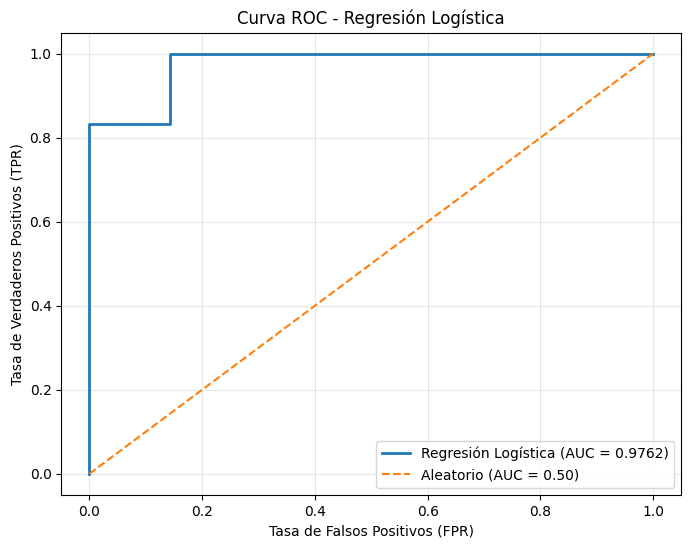

In [23]:
# ============================================================
# REGRESIÓN LOGÍSTICA
# Métricas + ROC-AUC
# ============================================================

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Crear modelo
# ------------------------------------------------------------

modelo_logistico = LogisticRegression(
    max_iter=1000
)


# ------------------------------------------------------------
# Entrenar
# MISMA división utilizada en KNN
# ------------------------------------------------------------

modelo_logistico.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# Comprobar clases
# ------------------------------------------------------------

print(
    "Clases:",
    modelo_logistico.classes_
)


# ------------------------------------------------------------
# Predicciones
# ------------------------------------------------------------

predicciones_logistica = modelo_logistico.predict(
    X_test
)


# ------------------------------------------------------------
# Probabilidades de la clase 1
# ------------------------------------------------------------

indice_clase_1 = np.where(
    modelo_logistico.classes_ == 1
)[0][0]

probabilidades_logistica = (
    modelo_logistico.predict_proba(X_test)
    [:, indice_clase_1]
)


# ------------------------------------------------------------
# Métricas
# ------------------------------------------------------------

accuracy_logistica = accuracy_score(
    y_test,
    predicciones_logistica
)

precision_logistica = precision_score(
    y_test,
    predicciones_logistica,
    average="weighted",
    zero_division=0
)

recall_logistica = recall_score(
    y_test,
    predicciones_logistica,
    average="weighted",
    zero_division=0
)

f1_logistica = f1_score(
    y_test,
    predicciones_logistica,
    average="weighted",
    zero_division=0
)


# ------------------------------------------------------------
# ROC-AUC
# ------------------------------------------------------------

roc_auc_logistica = roc_auc_score(
    y_test,
    probabilidades_logistica
)


# ------------------------------------------------------------
# Curva ROC
# ------------------------------------------------------------

fpr_logistica, tpr_logistica, thresholds_logistica = roc_curve(
    y_test,
    probabilidades_logistica
)


# ------------------------------------------------------------
# Mostrar resultados
# ------------------------------------------------------------

print("\nREGRESIÓN LOGÍSTICA")
print("=" * 50)

print(f"Accuracy : {accuracy_logistica:.4f}")
print(f"Precision: {precision_logistica:.4f}")
print(f"Recall   : {recall_logistica:.4f}")
print(f"F1-Score : {f1_logistica:.4f}")
print(f"ROC-AUC  : {roc_auc_logistica:.4f}")


# ------------------------------------------------------------
# Matriz de confusión
# ------------------------------------------------------------

print("\nMatriz de confusión:")

print(
    confusion_matrix(
        y_test,
        predicciones_logistica
    )
)


# ------------------------------------------------------------
# Reporte
# ------------------------------------------------------------

print("\nReporte de clasificación:")

print(
    classification_report(
        y_test,
        predicciones_logistica,
        zero_division=0
    )
)


# ------------------------------------------------------------
# Gráfica ROC
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistica,
    tpr_logistica,
    linewidth=2,
    label=f"Regresión Logística (AUC = {roc_auc_logistica:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Aleatorio (AUC = 0.50)"
)

plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")

plt.title(
    "Curva ROC - Regresión Logística"
)

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

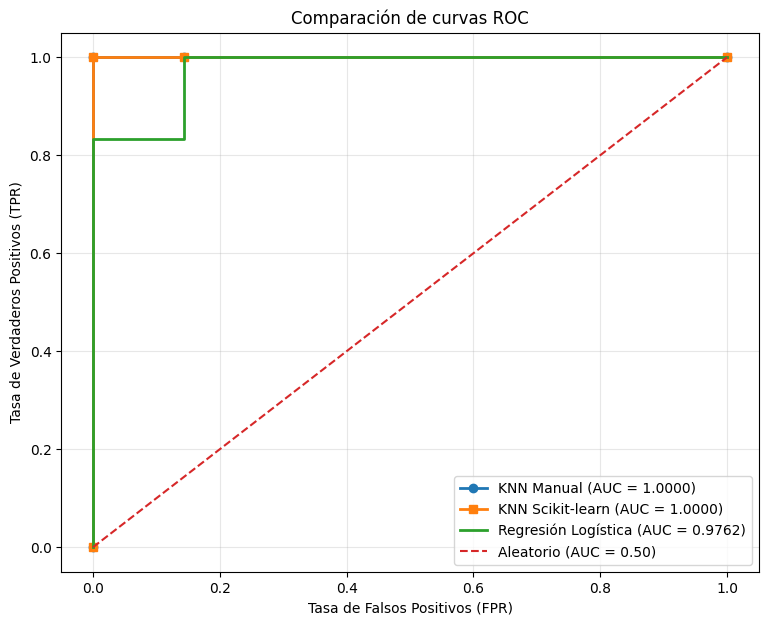

In [24]:
# ============================================================
# COMPARACIÓN DE CURVAS ROC
# ============================================================

plt.figure(figsize=(9, 7))


# KNN Manual
plt.plot(
    fpr_knn_manual,
    tpr_knn_manual,
    marker="o",
    linewidth=2,
    label=f"KNN Manual (AUC = {roc_auc_knn_manual:.4f})"
)


# KNN Scikit-learn
plt.plot(
    fpr_knn_sklearn,
    tpr_knn_sklearn,
    marker="s",
    linewidth=2,
    label=f"KNN Scikit-learn (AUC = {roc_auc_knn_sklearn:.4f})"
)


# Regresión Logística
plt.plot(
    fpr_logistica,
    tpr_logistica,
    linewidth=2,
    label=f"Regresión Logística (AUC = {roc_auc_logistica:.4f})"
)


# Clasificador aleatorio
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Aleatorio (AUC = 0.50)"
)


plt.xlabel(
    "Tasa de Falsos Positivos (FPR)"
)

plt.ylabel(
    "Tasa de Verdaderos Positivos (TPR)"
)

plt.title(
    "Comparación de curvas ROC"
)

plt.legend(
    loc="lower right"
)

plt.grid(alpha=0.3)

plt.show()